In [47]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

In [48]:
X_train=np.load("X_train0.npy")
X_test=np.load("X_test0.npy")
y_train=np.load("y_train0.npy")
y_test=np.load("y_test0.npy")

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(60, 64, 64, 18) (60, 64, 64, 1)
(61, 64, 64, 18) (61, 64, 64, 1)


In [49]:
X_train = torch.tensor(X_train).permute(0, 3, 1, 2).float()
y_train = torch.tensor(y_train).permute(0, 3, 1, 2).float()

X_test = torch.tensor(X_test).permute(0, 3, 1, 2).float()
y_test = torch.tensor(y_test).permute(0, 3, 1, 2).float()

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

In [61]:
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=8,
    shuffle=True
)

In [60]:
class SEBlock(nn.Module):
    def __init__(self, c, r=4):
        super().__init__()
        self.fc1 = nn.Conv2d(c, c // r, 1)
        self.fc2 = nn.Conv2d(c // r, c, 1)

    def forward(self, x):
        w = torch.mean(x, dim=(2,3), keepdim=True)
        w = torch.relu(self.fc1(w))
        w = torch.sigmoid(self.fc2(w))
        return x * w

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.d1 = DoubleConv(in_channels, 64)
        self.p1 = nn.MaxPool2d(2)

        self.d2 = DoubleConv(64, 128)
        self.p2 = nn.MaxPool2d(2)

        self.d3 = DoubleConv(128, 256)
        self.p3 = nn.MaxPool2d(2)

        self.bn = DoubleConv(256, 512)

        self.u3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.c3 = DoubleConv(512, 256)

        self.u2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.c2 = DoubleConv(256, 128)

        self.u1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.c1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

        # ✅ Context-aware fusion
        self.se = SEBlock(19)
        self.fuse = nn.Conv2d(19, 1, 1)

    def forward(self, x):
        x_in = x

        d1 = self.d1(x)
        d2 = self.d2(self.p1(d1))
        d3 = self.d3(self.p2(d2))

        bn = self.bn(self.p3(d3))

        u3 = self.c3(torch.cat([self.u3(bn), d3], dim=1))
        u2 = self.c2(torch.cat([self.u2(u3), d2], dim=1))
        u1 = self.c1(torch.cat([self.u1(u2), d1], dim=1))

        out = self.out(u1)                    # (B,1,H,W)
        s2_pre = x_in[:, :, :, :]           # (B,5,H,W)

        fused = torch.cat([out, s2_pre], dim=1)  # (B,6,H,W)

        fused = self.se(fused)                # ✅ context-aware weighting
        out = self.fuse(fused)                # (B,1,H,W)

        return out   # ⚠️ NO sigmoid here (important)

In [59]:
import torch.nn.functional as F

def loss_fn(y_true, logits, model, l1_lambda=1e-4):
    probs = torch.sigmoid(logits)

    # BCE + Dice
    intersection = (probs * y_true).sum()
    dice = 1 - (2 * intersection + 1e-6) / (probs.sum() + y_true.sum() + 1e-6)

    loss = F.binary_cross_entropy(probs, y_true) + dice

    # L1 regularization on fusion weights
    loss += l1_lambda * model.fuse.weight.abs().sum()

    return loss

In [62]:
model = UNet(in_channels=X_train.shape[1]).to(device)

In [63]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

In [68]:
for epoch in range(30):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()

        logits = model(xb)   # raw output
        loss = loss_fn(yb, logits, model)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}, Loss: {total_loss:.4f}")

Epoch 0, Loss: 12.4239
Epoch 1, Loss: 12.3887
Epoch 2, Loss: 12.3670
Epoch 3, Loss: 12.3238
Epoch 4, Loss: 12.2960
Epoch 5, Loss: 12.2707
Epoch 6, Loss: 12.2456
Epoch 7, Loss: 12.2080
Epoch 8, Loss: 12.1748
Epoch 9, Loss: 12.1625
Epoch 10, Loss: 12.1289
Epoch 11, Loss: 12.0983
Epoch 12, Loss: 12.0553
Epoch 13, Loss: 12.0217
Epoch 14, Loss: 11.9841
Epoch 15, Loss: 11.9527
Epoch 16, Loss: 11.9197
Epoch 17, Loss: 11.8905
Epoch 18, Loss: 11.8555
Epoch 19, Loss: 11.8213
Epoch 20, Loss: 11.7907
Epoch 21, Loss: 11.7531
Epoch 22, Loss: 11.7320
Epoch 23, Loss: 11.6956
Epoch 24, Loss: 11.6688
Epoch 25, Loss: 11.6346
Epoch 26, Loss: 11.5999
Epoch 27, Loss: 11.5633
Epoch 28, Loss: 11.5331
Epoch 29, Loss: 11.4994


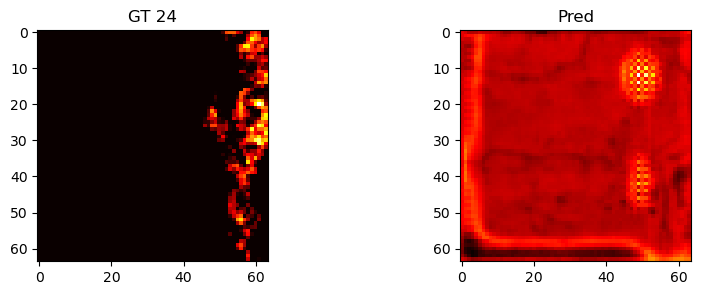

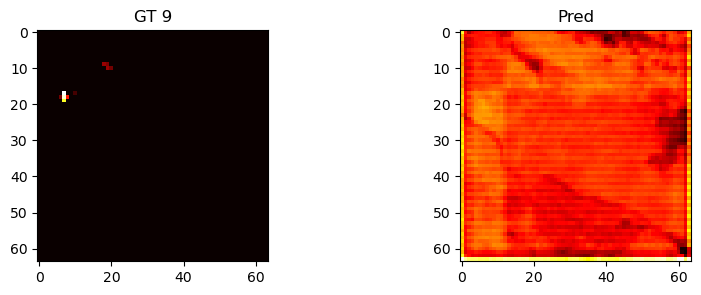

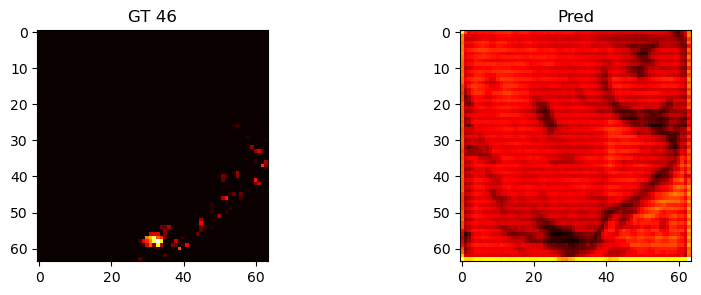

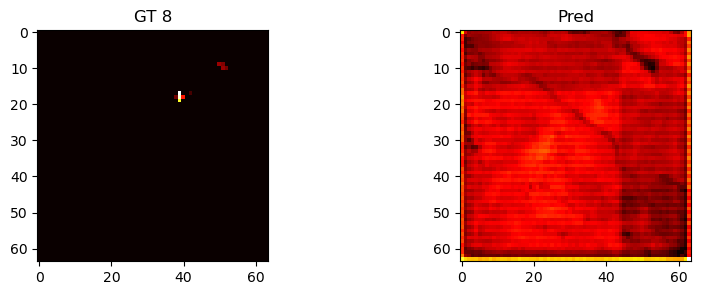

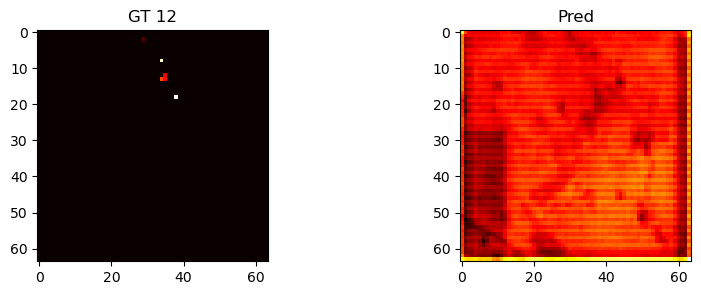

In [70]:
import random

model.eval()

indices = random.sample(range(len(X_test)), 5)

with torch.no_grad():
    preds = torch.sigmoid(model(X_test[indices]))

for j, i in enumerate(indices):
    plt.figure(figsize=(10,3))
    
    plt.subplot(1,2,1)
    plt.imshow(y_test[i][0].cpu(), cmap='hot')
    plt.title(f"GT {i}")
    
    plt.subplot(1,2,2)
    plt.imshow(preds[j][0].cpu(), cmap='hot')
    plt.title("Pred")
    
    plt.show()

In [45]:
weights = model.fuse.weight.data.cpu().numpy()  # shape: (1,6,1,1)
weights = weights.reshape(-1)

In [46]:
print("Pred influence:", weights[0])
print("Band influences:", weights[1:])

Pred influence: 0.19276004
Band influences: [ 0.17686592  0.0522216   0.2584955  -0.3428986  -0.31325683]
